In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [2]:
import random
import numpy as np
import torch

def set_seed(seed: int):
    # Python
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # Numpy
    np.random.seed(seed)

    # Torch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # cuDNN (중요)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # PyTorch 2.x (있으면 더 강력)
    torch.use_deterministic_algorithms(True)

seed = 0
set_seed(seed)

In [3]:
# ================================================================
# Step 1: 데이터 로더 (ETTh1 / Weather)
# ================================================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

class TSDataset(Dataset):
    """
    ETTh1, ETTm1, Weather 등 표준 CSV 포맷 지원
    입력: (seq_len, n_vars), 출력: (pred_len, n_vars)
    DataLoader 통과 후: (B, n_vars, seq_len) / (B, n_vars, pred_len)
    """
    def __init__(self, data_path, flag='train',
                 seq_len=336, pred_len=96, 
                 target_col=None, scale=True):
        assert flag in ['train', 'val', 'test']
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.scale    = scale

        df = pd.read_csv(data_path)

        # 날짜 컬럼 제거 (있으면)
        if 'date' in df.columns:
            df = df.drop(columns=['date'])
        
        data = df.values.astype(np.float32)   # (T, C)
        T = len(data)

        # 표준 7:1:2 split
        border = {
            'train': (0,             int(T * 0.7)),
            'val':   (int(T * 0.7),  int(T * 0.8)),
            'test':  (int(T * 0.8),  T),
        }
        s, e = border[flag]

        scaler = StandardScaler()
        # scaler는 train으로만 fit
        scaler.fit(data[:int(T * 0.7)])
        self.data = scaler.transform(data)[s:e]   # (split_T, C)

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx           : idx + self.seq_len]   # (seq_len, C)
        y = self.data[idx+self.seq_len : idx+self.seq_len+self.pred_len]  # (pred_len, C)
        # (C, T) 형태로 반환 — 모델 입력 규격에 맞춤
        return {
            "x": torch.tensor(x).T,   # (C, seq_len)
            "y": torch.tensor(y).T,   # (C, pred_len)
        }


def get_ts_loader(dataset_name, batch_size=32, seq_len=336, pred_len=96,
                  data_root='./data'):
    """
    dataset_name: 'ETTh1' | 'Weather'
    반환: train_loader, val_loader, test_loader, n_vars
    """
    paths = {
        'ETTh1':   os.path.join(data_root, 'ETT-small/ETTh1.csv'),
        'ETTm1':   os.path.join(data_root, 'ETT-small/ETTm1.csv'),
        'Weather': os.path.join(data_root, 'weather/weather.csv'),
    }
    assert dataset_name in paths, f"지원하지 않는 데이터셋: {dataset_name}"
    path = paths[dataset_name]

    loaders = {}
    for flag in ['train', 'val', 'test']:
        ds = TSDataset(path, flag=flag, seq_len=seq_len, pred_len=pred_len)
        loaders[flag] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(flag == 'train'),
            num_workers=2, pin_memory=True, drop_last=(flag=='train')
        )

    # 변수(채널) 수 확인
    sample = next(iter(loaders['train']))
    n_vars = sample['x'].shape[1]   # (B, C, T) → C

    print(f"[{dataset_name}] n_vars={n_vars}, "
          f"train={len(loaders['train'].dataset)}, "
          f"val={len(loaders['val'].dataset)}, "
          f"test={len(loaders['test'].dataset)}")

    return loaders['train'], loaders['val'], loaders['test'], n_vars


In [4]:
import torch
import torch.nn as nn
from tqdm.notebook import tqdm
import copy
# ================================================================
# Step 2: PatchTST / DLinear
# ================================================================

class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(1, num_features, 1))
        self.affine_bias = nn.Parameter(torch.zeros(1, num_features, 1))

    def forward(self, x, mode='norm'):
        if mode == 'norm':
            self.mean = x.mean(dim=-1, keepdim=True)
            self.stdev = torch.sqrt(torch.var(x, dim=-1, keepdim=True, unbiased=False) + self.eps)
            return (x - self.mean) / (self.stdev + self.eps) * self.affine_weight + self.affine_bias
        else: # denorm
            return (x - self.affine_bias) / (self.affine_weight + self.eps) * self.stdev + self.mean

class MLP(nn.Module):
    def __init__(self, in_features, out_features, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_features)
        )
    def forward(self, x):
        return self.net(x)
        
# ── DLinear ──────────────────────────────────────────────────────
class DLinear(nn.Module):
    def __init__(self, seq_len, pred_len, n_vars, individual=False):
        super().__init__()
        self.revin = RevIN(n_vars)
        self.avg_pool = nn.AvgPool1d(kernel_size=25, stride=1, padding=12)
        
        if individual:
            self.trend_proj = nn.ModuleList([MLP(seq_len, pred_len) for _ in range(n_vars)])
            self.res_proj = nn.ModuleList([MLP(seq_len, pred_len) for _ in range(n_vars)])
        else:
            self.trend_proj = MLP(seq_len, pred_len)
            self.res_proj = MLP(seq_len, pred_len)
        self.individual = individual

    def decompose(self, x):
        trend = self.avg_pool(x)
        return trend, x - trend

    def forward(self, x):
        x = self.revin(x, 'norm') # RevIN 적용
        trend, res = self.decompose(x)

        if self.individual:
            t_out = torch.stack([self.trend_proj[i](trend[:, i, :]) for i in range(trend.size(1))], dim=1)
            r_out = torch.stack([self.res_proj[i](res[:, i, :]) for i in range(res.size(1))], dim=1)
        else:
            t_out = self.trend_proj(trend)
            r_out = self.res_proj(res)

        out = t_out + r_out
        return self.revin(out, 'denorm') # 역정규화 적용

# ── PatchTST ─────────────────────────────────────────────────────
class PatchTST(nn.Module):
    def __init__(self, seq_len, pred_len, n_vars, patch_len=16, stride=8,
                 d_model=128, n_heads=8, n_layers=3, d_ff=256, dropout=0.1):
        super().__init__()
        self.revin = RevIN(n_vars) # RevIN 적용
        self.patch_len = patch_len
        self.stride = stride
        self.n_patches = (seq_len - patch_len) // stride + 1

        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        self.dropout = nn.Dropout(dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # 예측 헤드: MLP로 강화
        self.head = MLP(self.n_patches * d_model, pred_len, hidden_dim=d_ff)

    def forward(self, x):
        x = self.revin(x, 'norm') # RevIN 적용
        B, C, T = x.shape
        
        # Patching
        x_patch = x.unfold(-1, self.patch_len, self.stride).reshape(B * C, self.n_patches, self.patch_len)
        z = self.patch_embed(x_patch) + self.pos_embed
        z = self.dropout(z)
        
        # Transformer
        z = self.encoder(z)
        
        # Prediction
        z = z.reshape(B * C, -1)
        out = self.head(z)
        out = out.reshape(B, C, -1)
        
        return self.revin(out, 'denorm') # 역정규화 적용

# ── 모델 팩토리 ───────────────────────────────────────────────────
def build_model(model_type, n_vars, seq_len, pred_len, device):
    if model_type == 'PatchTST':
        model = PatchTST(
            seq_len=seq_len, pred_len=pred_len, n_vars=n_vars,
            patch_len=16, stride=8,
            d_model=128, n_heads=8, n_layers=3
        )
    elif model_type == 'DLinear':
        model = DLinear(
            seq_len=seq_len, pred_len=pred_len, n_vars=n_vars,
            individual=False     # shared Linear — 빠르고 안정적
        )
    else:
        raise ValueError(f"Unknown model: {model_type}")
    return model.to(device)

In [5]:
# ================================================================
# fine_tune — 변경 없음 (이미 shape-agnostic)
# ================================================================
def fine_tune(model, optimizer, criterion, train_loader, device):
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        inputs  = batch["x"].to(device)
        targets = batch["y"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    return model, copy.deepcopy(model.state_dict()), train_loss / len(train_loader)


# ================================================================
# studygroup — 핵심 수정: 4D 인덱싱 → Boolean mask
# ================================================================
def studygroup(model1, model2, optimizer1, optimizer2,
               criterion, train_loader, device):
    model1.train()
    model2.train()
    train_loss1 = 0.0
    train_loss2 = 0.0

    for batch in train_loader:
        inputs  = batch["x"].to(device)   # (B, C, T)
        targets = batch["y"].to(device)   # (B, C, pred_len)

        optimizer1.zero_grad()
        optimizer2.zero_grad()

        out1 = model1(inputs)
        out2 = model2(inputs)

        # ---- SSML 마스크 계산 ----------------------------------------
        # 기존: torch.abs(outputs1 - targets) → 동일한 의미, 이름만 정리
        gap  = torch.abs(out1 - targets) > torch.abs(out2 - targets)
        sign = torch.sign(out1 - targets) != torch.sign(out2 - targets)

        mask1 = gap & sign        # model1이 더 틀리고 방향도 반대 → out2에게 배움
        mask2 = (~gap) & sign     # model2가 더 틀리고 방향도 반대 → out1에게 배움
        mask3 = ~sign             # 방향이 같음 → 각자 GT로 학습

        # ---- model1 loss ---------------------------------------------
        # 버그 수정: 초기값을 0으로 명시, 조건 없을 때 0 gradient 보장
        loss1 = torch.tensor(0.0, device=device, requires_grad=False)

        if mask1.any():
            # 기존 4D: outputs1[index1[0], index1[1], index1[2], index1[3]]
            # 수정:    out1[mask1]  ← 3D/4D 모두 동작
            loss1 = criterion(out1[mask1], out2[mask1].detach())

        if mask3.any():
            # 기존 4D: outputs1[index3[0], index3[1], index3[2], index3[3]]
            # 수정:    out1[mask3]
            loss1 = loss1 + criterion(out1[mask3], targets[mask3])

        # mask1, mask3 모두 비어있으면 gradient 없이 skip
        if mask1.any() or mask3.any():
            loss1.backward()
            optimizer1.step()

        # ---- model2 loss ---------------------------------------------
        loss2 = torch.tensor(0.0, device=device, requires_grad=False)

        if mask2.any():
            loss2 = criterion(out2[mask2], out1[mask2].detach())

        if mask3.any():
            loss2 = loss2 + criterion(out2[mask3], targets[mask3])

        if mask2.any() or mask3.any():
            loss2.backward()
            optimizer2.step()

        train_loss1 += loss1.item()
        train_loss2 += loss2.item()

    n = len(train_loader)
    return (model1, model2,
            copy.deepcopy(model1.state_dict()),
            copy.deepcopy(model2.state_dict()),
            train_loss1 / n, train_loss2 / n)

def dml(model1, model2, optimizer1, optimizer2,
              criterion, distillation_loss_fn, alpha,
              train_loader, device):
    """
    Standard Deep Mutual Learning (DML)
    alpha: Distillation loss의 가중치
    distillation_loss_fn: 모델 간 지식 전달을 위한 함수 (예: KLDiv, MSE)
    """
    model1.train()
    model2.train()
    train_loss1 = 0.0
    train_loss2 = 0.0

    for batch in train_loader:
        inputs = batch["x"].to(device)
        targets = batch["y"].to(device)

        optimizer1.zero_grad()
        optimizer2.zero_grad()

        out1 = model1(inputs)
        out2 = model2(inputs)

        # 1. Supervised Loss (각자 정답(GT)과 비교)
        loss1_sup = criterion(out1, targets)
        loss2_sup = criterion(out2, targets)

        # 2. Distillation Loss (상대방의 예측값과 비교)
        # model1은 model2의 지식을 배우고, model2는 model1의 지식을 배움
        # detach()를 통해 상대방의 그래디언트 흐름을 끊어줌 (Standard DML)
        loss1_dist = distillation_loss_fn(out1, out2.detach())
        loss2_dist = distillation_loss_fn(out2, out1.detach())

        # 3. Total Loss
        loss1 = loss1_sup + alpha * loss1_dist
        loss2 = loss2_sup + alpha * loss2_dist

        loss1.backward()
        loss2.backward()

        optimizer1.step()
        optimizer2.step()

        train_loss1 += loss1.item()
        train_loss2 += loss2.item()

    n = len(train_loader)
    return model1, model2, train_loss1 / n, train_loss2 / n
    
# ================================================================
# evaluate — TS 표준 메트릭(MAE + MSE) 추가
# ================================================================
def evaluate(model, test_loader, device):
    model.eval()

    total_mse     = 0.0
    total_mae     = 0.0
    total_rel_l2  = 0.0
    count = 0

    with torch.no_grad():
        for batch in test_loader:
            inputs  = batch["x"].to(device)
            targets = batch["y"].to(device)
            outputs = model(inputs)

            diff = outputs - targets
            B    = targets.size(0)

            # MSE / MAE (TS 논문 표준)
            total_mse += (diff ** 2).mean().item() * B
            total_mae += diff.abs().mean().item()  * B

            # Relative L2 (operator learning과 동일한 척도 — 비교용으로 유지)
            diff_norm   = torch.norm(diff.view(B, -1),    dim=1)
            target_norm = torch.norm(targets.view(B, -1), dim=1)
            total_rel_l2 += (diff_norm / (target_norm + 1e-12)).sum().item()

            count += B

    return {
        "mse":    total_mse   / count,
        "mae":    total_mae   / count,
        "rel_l2": total_rel_l2 / count,
    }

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ETTh1
train_loader, val_loader, test_loader, n_vars = get_ts_loader(
    'Weather', batch_size=32, seq_len=336, pred_len=96
)
# → [ETTh1] n_vars=7, train=8001, val=2881, test=2881

# 모델 생성 (이종 쌍)
model1 = build_model('PatchTST', n_vars, seq_len=336, pred_len=96, device=device)
model2 = build_model('DLinear',  n_vars, seq_len=336, pred_len=96, device=device)


[Weather] n_vars=21, train=36456, val=4838, test=10109


print(pretrained_model1)
print(pretrained_model3)
print(pretrained_model4)

In [7]:
# ================================================================
# 단일 모델 실험 (Baseline fine-tune)
# ================================================================
def run_experiment_ts(seed, dataset_name='ETTh1', model_type='PatchTST',
                      seq_len=336, pred_len=96, epochs=100, batch_size=32):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 데이터 로더 — val_loader는 early stopping용으로 받아둠
    train_loader, val_loader, test_loader, n_vars = get_ts_loader(
        dataset_name, batch_size=batch_size,
        seq_len=seq_len, pred_len=pred_len
    )

    # 매 실험마다 새로 초기화 (pretrained 없음 — TS는 from scratch가 표준)
    model = build_model(model_type, n_vars, seq_len, pred_len, device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    train_curve = []
    val_curve   = []   # early stopping 모니터링용
    test_curve  = []
    best_test   = float("inf")
    best_val    = float("inf")
    best_state  = None

    for epoch in tqdm(range(epochs), desc=f"{dataset_name}/{model_type}/seed{seed}"):
        # fine_tune은 수정 없이 그대로 사용
        model, _, train_loss = fine_tune(
            model, optimizer, criterion, train_loader, device=device
        )

        # evaluate가 이제 dict 반환 → MSE 기준으로 tracking
        val_metrics  = evaluate(model, val_loader,  device)
        test_metrics = evaluate(model, test_loader, device)

        train_curve.append(train_loss)
        val_curve.append(val_metrics["mse"])
        test_curve.append(test_metrics["mse"])

        # best는 val 기준으로 선택 (test leakage 방지)
        if val_metrics["mse"] < best_val:
            best_val   = val_metrics["mse"]
            best_state = copy.deepcopy(model.state_dict())
            best_test  = test_metrics["mse"]   # val best 시점의 test 성능
        scheduler.step()

    return {
        "best_mse":    best_test,
        "best_val":    best_val,
        "train_curve": np.array(train_curve),
        "val_curve":   np.array(val_curve),
        "test_curve":  np.array(test_curve),
        "best_state":  best_state,            # 모델 재현용
    }


In [8]:
# ================================================================
# SSML 쌍 실험 (studygroup)
# ================================================================
def run_experiment_ssml_ts(seed, dataset_name='ETTh1',
                           model1_type='PatchTST', model2_type='DLinear',
                           seq_len=336, pred_len=96, epochs=100, batch_size=32):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, test_loader, n_vars = get_ts_loader(
        dataset_name, batch_size=batch_size,
        seq_len=seq_len, pred_len=pred_len
    )

    model1 = build_model(model1_type, n_vars, seq_len, pred_len, device)
    model2 = build_model(model2_type, n_vars, seq_len, pred_len, device)

    optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-4)
    optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=epochs)
    scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=epochs)
    criterion  = nn.MSELoss()

    # model1
    train_curve1 = []
    val_curve1   = []
    test_curve1  = []
    best_val1    = float("inf")
    best_test1   = float("inf")
    best_state1  = None

    # model2
    train_curve2 = []
    val_curve2   = []
    test_curve2  = []
    best_val2    = float("inf")
    best_test2   = float("inf")
    best_state2  = None

    desc = f"{dataset_name}/{model1_type}+{model2_type}/seed{seed}"
    for epoch in tqdm(range(epochs), desc=desc):

        # studygroup — lr 인자 제거됨 (이전 수정 반영)
        model1, model2, _, _, train_loss1, train_loss2 = studygroup(
            model1, model2, optimizer1, optimizer2,
            criterion, train_loader, device=device
        )

        val_metrics1  = evaluate(model1, val_loader,  device)
        val_metrics2  = evaluate(model2, val_loader,  device)
        test_metrics1 = evaluate(model1, test_loader, device)
        test_metrics2 = evaluate(model2, test_loader, device)

        train_curve1.append(train_loss1)
        val_curve1.append(val_metrics1["mse"])
        test_curve1.append(test_metrics1["mse"])

        train_curve2.append(train_loss2)
        val_curve2.append(val_metrics2["mse"])
        test_curve2.append(test_metrics2["mse"])

        # val 기준 best (run_experiment_ts와 동일한 기준)
        if val_metrics1["mse"] < best_val1:
            best_val1   = val_metrics1["mse"]
            best_test1  = test_metrics1["mse"]
            best_state1 = copy.deepcopy(model1.state_dict())

        if val_metrics2["mse"] < best_val2:
            best_val2   = val_metrics2["mse"]
            best_test2  = test_metrics2["mse"]
            best_state2 = copy.deepcopy(model2.state_dict())

        scheduler1.step()
        scheduler2.step()

    return {
        "best_mse1":   best_test1,
        "best_val1":   best_val1,
        "train_curve1": np.array(train_curve1),
        "val_curve1":   np.array(val_curve1),
        "test_curve1":  np.array(test_curve1),
        "best_state1":  best_state1,

        "best_mse2":   best_test2,
        "best_val2":   best_val2,
        "train_curve2": np.array(train_curve2),
        "val_curve2":   np.array(val_curve2),
        "test_curve2":  np.array(test_curve2),
        "best_state2":  best_state2,
    }

In [9]:
# ================================================================
# DML 쌍 실험 (Deep Mutual Learning)
# ================================================================
def run_experiment_dml_ts(seed, dataset_name='ETTh1',
                          model1_type='PatchTST', model2_type='DLinear',
                          seq_len=336, pred_len=96, epochs=100, batch_size=32,
                          alpha=0.5): # DML 전용: distillation loss 가중치
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, test_loader, n_vars = get_ts_loader(
        dataset_name, batch_size=batch_size,
        seq_len=seq_len, pred_len=pred_len
    )

    model1 = build_model(model1_type, n_vars, seq_len, pred_len, device)
    model2 = build_model(model2_type, n_vars, seq_len, pred_len, device)

    optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-4)
    optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=epochs)
    scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=epochs)
    
    # DML 설정
    criterion = nn.MSELoss()
    distillation_fn = nn.MSELoss() # 시계열이므로 MSE 사용

    # model1 / model2 상태 기록용 변수들 (SSML과 동일)
    train_curve1, val_curve1, test_curve1 = [], [], []
    best_val1, best_test1, best_state1 = float("inf"), float("inf"), None

    train_curve2, val_curve2, test_curve2 = [], [], []
    best_val2, best_test2, best_state2 = float("inf"), float("inf"), None

    desc = f"DML_{dataset_name}/{model1_type}+{model2_type}/seed{seed}"
    for epoch in tqdm(range(epochs), desc=desc):

        # dml_train 함수 호출
        model1, model2, train_loss1, train_loss2 = dml(
            model1, model2, optimizer1, optimizer2,
            criterion, distillation_fn, alpha,
            train_loader, device
        )

        val_metrics1  = evaluate(model1, val_loader, device)
        val_metrics2  = evaluate(model2, val_loader, device)
        test_metrics1 = evaluate(model1, test_loader, device)
        test_metrics2 = evaluate(model2, test_loader, device)

        train_curve1.append(train_loss1)
        val_curve1.append(val_metrics1["mse"])
        test_curve1.append(test_metrics1["mse"])

        train_curve2.append(train_loss2)
        val_curve2.append(val_metrics2["mse"])
        test_curve2.append(test_metrics2["mse"])

        # Best 모델 저장
        if val_metrics1["mse"] < best_val1:
            best_val1   = val_metrics1["mse"]
            best_test1  = test_metrics1["mse"]
            best_state1 = copy.deepcopy(model1.state_dict())

        if val_metrics2["mse"] < best_val2:
            best_val2   = val_metrics2["mse"]
            best_test2  = test_metrics2["mse"]
            best_state2 = copy.deepcopy(model2.state_dict())

        scheduler1.step()
        scheduler2.step()

    return {
        "best_mse1":   best_test1,
        "best_val1":   best_val1,
        "train_curve1": np.array(train_curve1),
        "val_curve1":   np.array(val_curve1),
        "test_curve1":  np.array(test_curve1),
        "best_state1":  best_state1,

        "best_mse2":   best_test2,
        "best_val2":   best_val2,
        "train_curve2": np.array(train_curve2),
        "val_curve2":   np.array(val_curve2),
        "test_curve2":  np.array(test_curve2),
        "best_state2":  best_state2,
    }

In [ ]:
seeds = [0, 1, 2, 3, 4]
# ETTh1과 완전히 동일한 구조, dataset_name만 변경

results_PatchTST_W = []
results_DLinear_W  = []
results_PT_PT_W    = []
results_DL_DL_W    = []
results_PT_DL_W    = []
results_dml_PT_PT_W = []
results_dml_DL_DL_W = []
results_dml_PT_DL_W = []

for seed in seeds:
    # Baseline
    results_PatchTST_W.append(
        run_experiment_ts(seed, dataset_name='Weather',
                          model_type='PatchTST', epochs=50))
    results_DLinear_W.append(
        run_experiment_ts(seed, dataset_name='Weather',
                          model_type='DLinear',  epochs=50))

    # SSML
    results_PT_PT_W.append(
        run_experiment_ssml_ts(seed, dataset_name='Weather',
                               model1_type='PatchTST', model2_type='PatchTST', epochs=50))
    results_DL_DL_W.append(
        run_experiment_ssml_ts(seed, dataset_name='Weather',
                               model1_type='DLinear',  model2_type='DLinear',  epochs=50))
    results_PT_DL_W.append(
        run_experiment_ssml_ts(seed, dataset_name='Weather',
                               model1_type='PatchTST', model2_type='DLinear',  epochs=50))

    # DML (있는 경우)
    results_dml_PT_PT_W.append(
        run_experiment_dml_ts(seed, dataset_name='Weather',
                              model1_type='PatchTST', model2_type='PatchTST', epochs=50))
    results_dml_DL_DL_W.append(
        run_experiment_dml_ts(seed, dataset_name='Weather',
                              model1_type='DLinear',  model2_type='DLinear',  epochs=50))
    results_dml_PT_DL_W.append(
        run_experiment_dml_ts(seed, dataset_name='Weather',
                              model1_type='PatchTST', model2_type='DLinear',  epochs=50))

[Weather] n_vars=21, train=36456, val=4838, test=10109


Weather/PatchTST/seed0:   0%|          | 0/50 [00:00<?, ?it/s]

[Weather] n_vars=21, train=36456, val=4838, test=10109


Weather/DLinear/seed0:   0%|          | 0/50 [00:00<?, ?it/s]

[Weather] n_vars=21, train=36456, val=4838, test=10109


...

Weather/PatchTST+PatchTST/seed3:   0%|          | 0/50 [00:00<?, ?it/s]

[Weather] n_vars=21, train=36456, val=4838, test=10109


Weather/DLinear+DLinear/seed3:   0%|          | 0/50 [00:00<?, ?it/s]

[Weather] n_vars=21, train=36456, val=4838, test=10109


Weather/PatchTST+DLinear/seed3:   0%|          | 0/50 [00:00<?, ?it/s]

In [81]:
import csv
import os

os.makedirs('results/ts', exist_ok=True)

# ================================================================
# 헬퍼 함수 — 반복 코드 제거
# ================================================================
def save_single(results, filepath):
    """run_experiment_ts 결과 저장"""
    fieldnames = ['best_mse', 'best_val',
                  'train_curve', 'val_curve', 'test_curve']
    with open(filepath, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in results:
            writer.writerow({
                'best_mse':    r['best_mse'],
                'best_val':    r['best_val'],
                'train_curve': r['train_curve'].tolist(),
                'val_curve':   r['val_curve'].tolist(),
                'test_curve':  r['test_curve'].tolist(),
            })

def save_ssml(results, filepath):
    """run_experiment_ssml_ts 결과 저장"""
    fieldnames = ['best_mse1', 'best_val1',
                  'train_curve1', 'val_curve1', 'test_curve1',
                  'best_mse2', 'best_val2',
                  'train_curve2', 'val_curve2', 'test_curve2']
    with open(filepath, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in results:
            writer.writerow({
                'best_mse1':   r['best_mse1'],
                'best_val1':   r['best_val1'],
                'train_curve1': r['train_curve1'].tolist(),
                'val_curve1':   r['val_curve1'].tolist(),
                'test_curve1':  r['test_curve1'].tolist(),
                'best_mse2':   r['best_mse2'],
                'best_val2':   r['best_val2'],
                'train_curve2': r['train_curve2'].tolist(),
                'val_curve2':   r['val_curve2'].tolist(),
                'test_curve2':  r['test_curve2'].tolist(),
            })

# ── 저장 ──────────────────────────────────────────────────
BASE_W = 'results/ts/Weather'
os.makedirs(BASE_W, exist_ok=True)

save_single(results_PatchTST_W, f'{BASE_W}/patchtst.csv')
save_single(results_DLinear_W,  f'{BASE_W}/dlinear.csv')

save_ssml(results_PT_PT_W,    f'{BASE_W}/patchtst_patchtst_ssml.csv')
save_ssml(results_DL_DL_W,    f'{BASE_W}/dlinear_dlinear_ssml.csv')
save_ssml(results_PT_DL_W,    f'{BASE_W}/patchtst_dlinear_ssml.csv')

save_ssml(results_dml_PT_PT_W, f'{BASE_W}/patchtst_patchtst_dml.csv')
save_ssml(results_dml_DL_DL_W, f'{BASE_W}/dlinear_dlinear_dml.csv')
save_ssml(results_dml_PT_DL_W, f'{BASE_W}/patchtst_dlinear_dml.csv')

print("Weather CSV 저장 완료")

# ── 시각화 — ETTh1 코드에서 3줄만 변경 ────────────────────
BASE = Path('results/ts/Weather')   # ← 경로 변경

r_pt  = load_csv(BASE / 'patchtst.csv')
r_dl  = load_csv(BASE / 'dlinear.csv')

r_pt_pt = load_csv(BASE / 'patchtst_patchtst_ssml.csv')
r_dl_dl = load_csv(BASE / 'dlinear_dlinear_ssml.csv')
r_pt_dl = load_csv(BASE / 'patchtst_dlinear_ssml.csv')

r_pt_pt_dml = load_csv(BASE / 'patchtst_patchtst_dml.csv')
r_dl_dl_dml = load_csv(BASE / 'dlinear_dlinear_dml.csv')
r_pt_dl_dml = load_csv(BASE / 'patchtst_dlinear_dml.csv')

# # suptitle만 변경, 나머지 시각화 코드 동일
# fig.suptitle("Weather — Test MSE Curve: Solo vs SSML vs DML", fontsize=13)
# # savefig 경로만 변경
# fig.savefig('results/ts/Weather/learning_curves.png', ...)
# fig.savefig('results/ts/Weather/bar_comparison.png',  ...)

CSV 저장 완료
results/ts/
  ETTh1/  patchtst.csv, dlinear.csv
          patchtst_patchtst.csv, dlinear_dlinear.csv, patchtst_dlinear.csv
  Weather/ (동일 구조)


In [84]:
# 1. PatchTST 데이터 추출
test_curves_pt = np.stack([r['test_curve'] for r in results_PatchTST])
best_pt = [r['best_mse'] for r in results_PatchTST]

# 2. DLinear 데이터 추출
test_curves_dl = np.stack([r['test_curve'] for r in results_DLinear])
best_dl = [r['best_mse'] for r in results_DLinear]

# 3. PT_DL (SSML) 데이터 추출
test_curves_pt_ssml = np.stack([r['test_curve1'] for r in results_PT_DL])
best_pt_ssml = [r['best_mse1'] for r in results_PT_DL]

test_curves_dl_ssml = np.stack([r['test_curve2'] for r in results_PT_DL])
best_dl_ssml = [r['best_mse2'] for r in results_PT_DL]

# 4. DML 데이터 추출 (DML 실험 결과를 담은 리스트를 여기 넣어주세요)
# 예: results_dml_PT_DL 등 사용
test_curves_pt_dml = np.stack([r['test_curve1'] for r in results_dml_PT_DL])
best_pt_dml = [r['best_mse1'] for r in results_dml_PT_DL]
test_curves_dl_dml = np.stack([r['test_curve2'] for r in results_dml_PT_DL])
best_dl_dml = [r['best_mse2'] for r in results_dml_PT_DL]

# 5. 이제 results_summary 정의
results_summary = {
    "PatchTST_Indep": {"curve": test_curves_pt, "best": best_pt},
    "DLinear_Indep":  {"curve": test_curves_dl, "best": best_dl},
    "PatchTST_SSML":  {"curve": test_curves_pt_ssml, "best": best_pt_ssml},
    "DLinear_SSML":   {"curve": test_curves_dl_ssml, "best": best_dl_ssml},
    "PatchTST_DML":   {"curve": test_curves_pt_dml, "best": best_pt_dml},
    "DLinear_DML":    {"curve": test_curves_dl_dml, "best": best_dl_dml},
}

In [85]:
import pandas as pd

summary_data = []
for name, data in results_summary.items():
    summary_data.append({
        "Method": name, 
        "Mean": np.mean(data["best"]), 
        "Std": np.std(data["best"])
    })

print(pd.DataFrame(summary_data).to_string(index=False))

        Method     Mean      Std
PatchTST_Indep 0.434233 0.005990
 DLinear_Indep 0.420616 0.005941
 PatchTST_SSML 0.414021 0.005734
  DLinear_SSML 0.413535 0.000854
  PatchTST_DML 0.421281 0.004427
   DLinear_DML 0.419635 0.006106


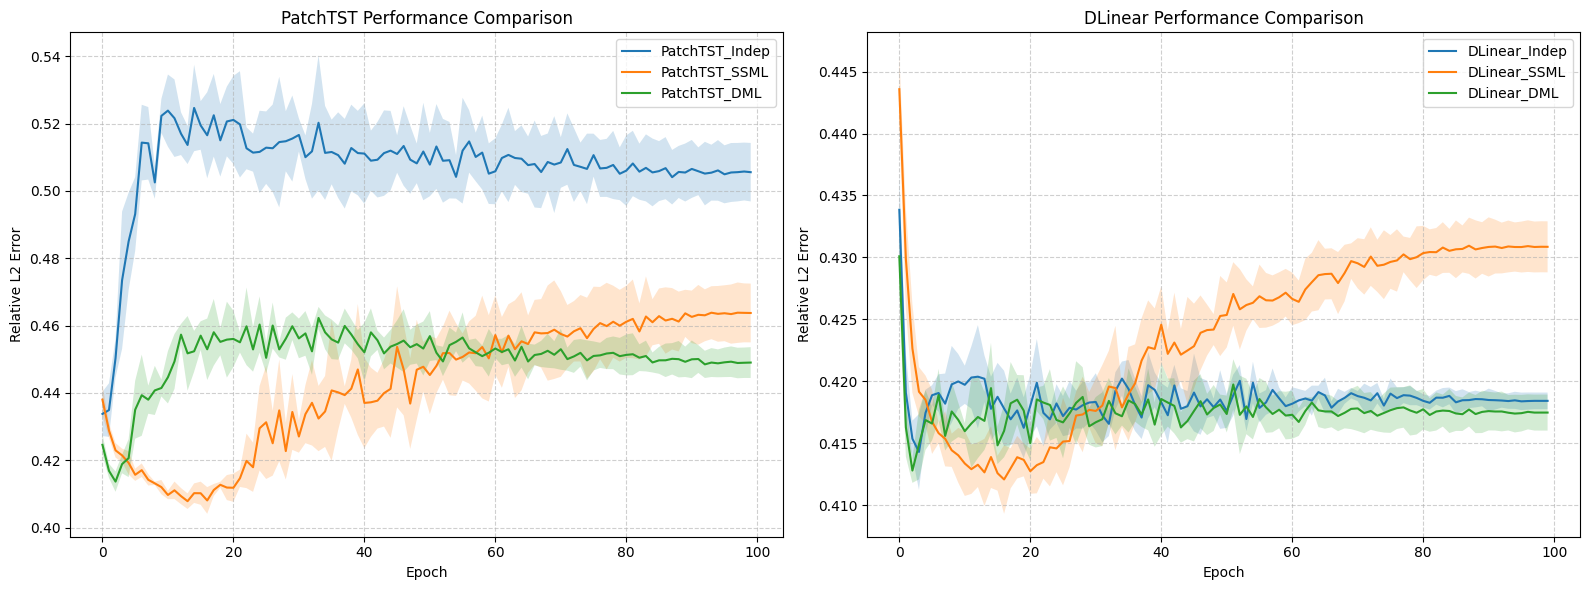

In [87]:
import matplotlib.pyplot as plt

# 1. 모델 타입 목록 정의 (keys에 포함된 이름)
model_types = ["PatchTST", "DLinear"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1행 2열 구조

for ax, m_type in zip(axes, model_types):
    ax.set_title(f"{m_type} Performance Comparison")
    
    # 해당 모델 타입이 포함된 데이터만 골라서 그리기
    for name, data in results_summary.items():
        if m_type in name:
            mean = np.mean(data["curve"], axis=0)
            std = np.std(data["curve"], axis=0)
            epochs = np.arange(len(mean))
            
            # plot 그리기
            ax.plot(epochs, mean, label=name)
            ax.fill_between(epochs, mean - std, mean + std, alpha=0.2)
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Relative L2 Error")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # 그래프 간 간격 자동 조절
plt.show()

In [68]:
# DeepONet-FNO Result

test_curves1 = np.stack([r["test_curve"] for r in results_PatchTST], axis=0)
# shape: (num_seeds, epochs)

mean_curve1 = test_curves1.mean(axis=0)
std_curve1 = test_curves1.std(axis=0)

best_mean1 = np.mean([r["best_mse"] for r in results_PatchTST])
best_std1 = np.std([r["best_mse"] for r in results_PatchTST])

test_curves2 = np.stack([r["test_curve"] for r in results_DLinear], axis=0)
# shape: (num_seeds, epochs)

mean_curve2 = test_curves2.mean(axis=0)
std_curve2 = test_curves2.std(axis=0)

best_mean2 = np.mean([r["best_mse"] for r in results_DLinear])
best_std2 = np.std([r["best_mse"] for r in results_DLinear])

test_curves3 = np.stack([r["test_curve1"] for r in results_PT_PT], axis=0)
# shape: (num_seeds, epochs)

mean_curve3 = test_curves3.mean(axis=0)
std_curve3 = test_curves3.std(axis=0)

best_mean3 = np.mean([r["best_mse1"] for r in results_PT_PT])
best_std3 = np.std([r["best_mse1"] for r in results_PT_PT])

test_curves4 = np.stack([r["test_curve2"] for r in results_PT_PT], axis=0)
# shape: (num_seeds, epochs)

mean_curve4 = test_curves4.mean(axis=0)
std_curve4 = test_curves4.std(axis=0)

best_mean4 = np.mean([r["best_mse2"] for r in results_PT_PT])
best_std4 = np.std([r["best_mse2"] for r in results_PT_PT])

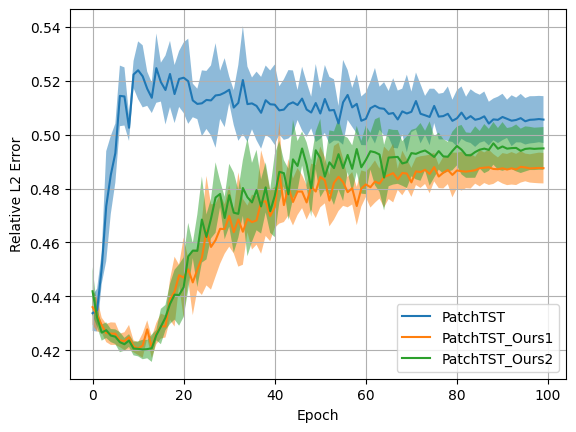

In [69]:
import matplotlib.pyplot as plt

epochs = np.arange(len(mean_curve1))

plt.plot(epochs[:], mean_curve1[:], label="PatchTST")
plt.fill_between(
    epochs[:],
    mean_curve1[:] - std_curve1[:],
    mean_curve1[:] + std_curve1[:],
    alpha=0.5
)
# plt.plot(epochs[:], mean_curve2[:], label="DLinear")
# plt.fill_between(
#     epochs[:],
#     mean_curve2[:] - std_curve2[:],
#     mean_curve2[:] + std_curve2[:],
#     alpha=0.5
# )
plt.plot(epochs[:], mean_curve4[:], label="PatchTST_Ours1")
plt.fill_between(
    epochs[:],
    mean_curve4[:] - std_curve4[:],
    mean_curve4[:] + std_curve4[:],
    alpha=0.5
)
plt.plot(epochs[:], mean_curve3[:], label="PatchTST_Ours2")
plt.fill_between(
    epochs[:],
    mean_curve3[:] - std_curve3[:],
    mean_curve3[:] + std_curve3[:],
    alpha=0.5
)

plt.xlabel("Epoch")
plt.ylabel("Relative L2 Error")
plt.legend()
plt.grid(True)

plt.show()


In [70]:
# DeepONet-FNO Result

test_curves1 = np.stack([r["test_curve"] for r in results_PatchTST], axis=0)
# shape: (num_seeds, epochs)

mean_curve1 = test_curves1.mean(axis=0)
std_curve1 = test_curves1.std(axis=0)

best_mean1 = np.mean([r["best_mse"] for r in results_PatchTST])
best_std1 = np.std([r["best_mse"] for r in results_PatchTST])

test_curves2 = np.stack([r["test_curve"] for r in results_DLinear], axis=0)
# shape: (num_seeds, epochs)

mean_curve2 = test_curves2.mean(axis=0)
std_curve2 = test_curves2.std(axis=0)

best_mean2 = np.mean([r["best_mse"] for r in results_DLinear])
best_std2 = np.std([r["best_mse"] for r in results_DLinear])

test_curves3 = np.stack([r["test_curve1"] for r in results_DL_DL], axis=0)
# shape: (num_seeds, epochs)

mean_curve3 = test_curves3.mean(axis=0)
std_curve3 = test_curves3.std(axis=0)

best_mean3 = np.mean([r["best_mse1"] for r in results_DL_DL])
best_std3 = np.std([r["best_mse1"] for r in results_DL_DL])

test_curves4 = np.stack([r["test_curve2"] for r in results_DL_DL], axis=0)
# shape: (num_seeds, epochs)

mean_curve4 = test_curves4.mean(axis=0)
std_curve4 = test_curves4.std(axis=0)

best_mean4 = np.mean([r["best_mse2"] for r in results_DL_DL])
best_std4 = np.std([r["best_mse2"] for r in results_DL_DL])

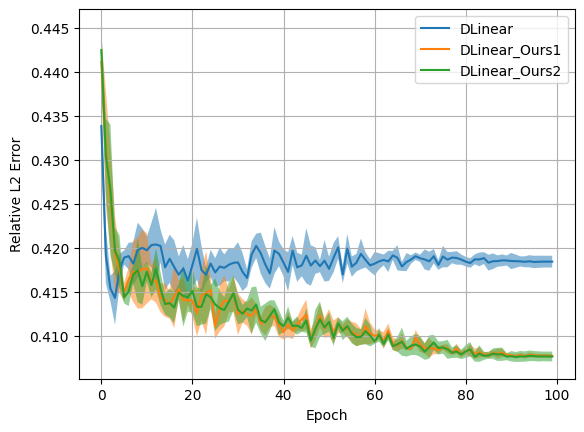

In [71]:
import matplotlib.pyplot as plt

epochs = np.arange(len(mean_curve1))

# plt.plot(epochs[:], mean_curve1[:], label="PatchTST")
# plt.fill_between(
#     epochs[:],
#     mean_curve1[:] - std_curve1[:],
#     mean_curve1[:] + std_curve1[:],
#     alpha=0.5
# )
plt.plot(epochs[:], mean_curve2[:], label="DLinear")
plt.fill_between(
    epochs[:],
    mean_curve2[:] - std_curve2[:],
    mean_curve2[:] + std_curve2[:],
    alpha=0.5
)
plt.plot(epochs[:], mean_curve4[:], label="DLinear_Ours1")
plt.fill_between(
    epochs[:],
    mean_curve4[:] - std_curve4[:],
    mean_curve4[:] + std_curve4[:],
    alpha=0.5
)
plt.plot(epochs[:], mean_curve3[:], label="DLinear_Ours2")
plt.fill_between(
    epochs[:],
    mean_curve3[:] - std_curve3[:],
    mean_curve3[:] + std_curve3[:],
    alpha=0.5
)

plt.xlabel("Epoch")
plt.ylabel("Relative L2 Error")
plt.legend()
plt.grid(True)

plt.show()
